# Индивидуальный проект: Python для автоматизации анализа данных

## Постановка задачи

**Выбранный датасет:** Video Game Sales  
**Ссылка на датасет:** https://www.kaggle.com/datasets/gregorut/videogamesales

**Тема задания:** Датасет 1 — Продажи игр.

**Цель исследования:** найти наиболее перспективный жанр игры для потенциальной разработки.

**Гипотеза:** существует жанр (возможно в связке с платформой), который продается лучше остальных.

---

**Автор:** Царюк Артём Владимирович

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Загрузка данных и первичный обзор

Использую локальные источники в приоритете (`vgsales.csv` или `archive.zip`), а затем онлайн-источники как запасной вариант.

In [2]:
from pathlib import Path
import zipfile

local_csv = Path('vgsales.csv')
local_zip = Path('archive.zip')
online_sources = [
    'https://raw.githubusercontent.com/GregorUT/vgcharts-db/master/vgcharts.csv',
    'https://raw.githubusercontent.com/plotly/datasets/master/vgsales.csv',
]

df = None
used_source = None
last_error = None

# 1) Локальный CSV
if local_csv.exists():
    df = pd.read_csv(local_csv)
    used_source = f'Локальный файл: {local_csv}'

# 2) Локальный ZIP (если CSV нет)
if df is None and local_zip.exists():
    try:
        with zipfile.ZipFile(local_zip, 'r') as zf:
            csv_names = [n for n in zf.namelist() if n.lower().endswith('.csv')]
            if not csv_names:
                raise FileNotFoundError('В archive.zip нет CSV-файлов')
            with zf.open(csv_names[0]) as f:
                df = pd.read_csv(f)
                used_source = f'ZIP: {local_zip} -> {csv_names[0]}'
    except Exception as e:
        last_error = e

# 3) Онлайн-источники (если локальные не сработали)
if df is None:
    for src in online_sources:
        try:
            df = pd.read_csv(src)
            used_source = f'URL: {src}'
            break
        except Exception as e:
            last_error = e

if df is None:
    raise FileNotFoundError(
        'Не удалось загрузить датасет автоматически. '\
        'Положите рядом с ноутбуком файл vgsales.csv или archive.zip. '\
        f'Последняя ошибка: {last_error}'
    )

print('Источник данных:', used_source)
print('Размер датасета:', df.shape)
df.head()

Источник данных: ZIP: archive.zip -> vgsales.csv
Размер датасета: (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,"2,006.00",Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,"1,985.00",Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,"2,008.00",Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,"2,009.00",Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 2. Предобработка данных

- Проверяю типы, пропуски и дубликаты.
- Привожу `Year` к числовому типу (`Int64`).
- Заполняю `Publisher` как `Unknown`.
- Удаляю строки с критичными пропусками (`Name`, `Platform`, `Genre`, `Year`).
- Добавляю признаки `Decade` и расчетные глобальные продажи.

In [3]:
df.info()

missing = df.isna().sum().sort_values(ascending=False)
print('\nПропуски:\n', missing[missing > 0])

df_clean = df.copy()
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce').round().astype('Int64')
df_clean['Publisher'] = df_clean['Publisher'].fillna('Unknown')
df_clean = df_clean.dropna(subset=['Name', 'Platform', 'Genre', 'Year'])

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

df_clean['Decade'] = (df_clean['Year'] // 10) * 10
df_clean['Global_Sales_Calc'] = (
    df_clean['NA_Sales'] + df_clean['EU_Sales'] + df_clean['JP_Sales'] + df_clean['Other_Sales']
).round(2)

print(f'Удалено дубликатов: {before - after}')
print('Итоговый размер:', df_clean.shape)
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB

Пропуски:
 Year         271
Publisher     58
dtype: int64
Удалено дубликатов: 0
Итоговый размер: (16327, 13)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Decade,Global_Sales_Calc
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,2000,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1980,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,2000,35.83
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,2000,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1990,31.38


**Вывод по предобработке:** данные пригодны для анализа; критичные пропуски удалены, типы нормализованы, созданы дополнительные аналитические колонки.

## 3. Описательные статистики

Считаю среднее, медиану, стандартное отклонение и агрегаты по жанрам.

In [4]:
num_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

stats = df_clean[num_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
display(stats)

genre_stats = (
    df_clean.groupby('Genre')['Global_Sales']
    .agg(['count', 'mean', 'median', 'std', 'sum'])
    .sort_values('sum', ascending=False)
)
display(genre_stats.head(10))

,count,mean,median,std,min,max
NA_Sales,"16,327.00",0.27,0.08,0.82,0.00,41.49
EU_Sales,"16,327.00",0.15,0.02,0.51,0.00,29.02
JP_Sales,"16,327.00",0.08,0.00,0.31,0.00,10.22
Other_Sales,"16,327.00",0.05,0.01,0.19,0.00,10.57
Global_Sales,"16,327.00",0.54,0.17,1.57,0.01,82.74


,count,mean,median,std,sum
Genre,,,,,
Action,3253,0.53,0.19,1.16,"1,722.88"
Sports,2304,0.57,0.22,2.10,"1,309.24"
Shooter,1282,0.80,0.23,1.83,"1,026.20"
Role-Playing,1471,0.63,0.19,1.72,923.84
Platform,876,0.95,0.28,2.60,829.15
Misc,1710,0.47,0.16,1.32,797.62
Racing,1226,0.59,0.19,1.68,726.77
Fighting,836,0.53,0.21,0.96,444.05
Simulation,851,0.46,0.16,1.21,390.16


**Вывод по статистикам:** продажи сильно асимметричны (среднее выше медианы), рынок формируют хиты; по суммарным продажам обычно лидируют `Action`, `Sports`, `Shooter`, `Role-Playing`.

## 4. Визуализация

Строю графики по жанрам, платформам, динамике по годам и связке `жанр × платформа`.

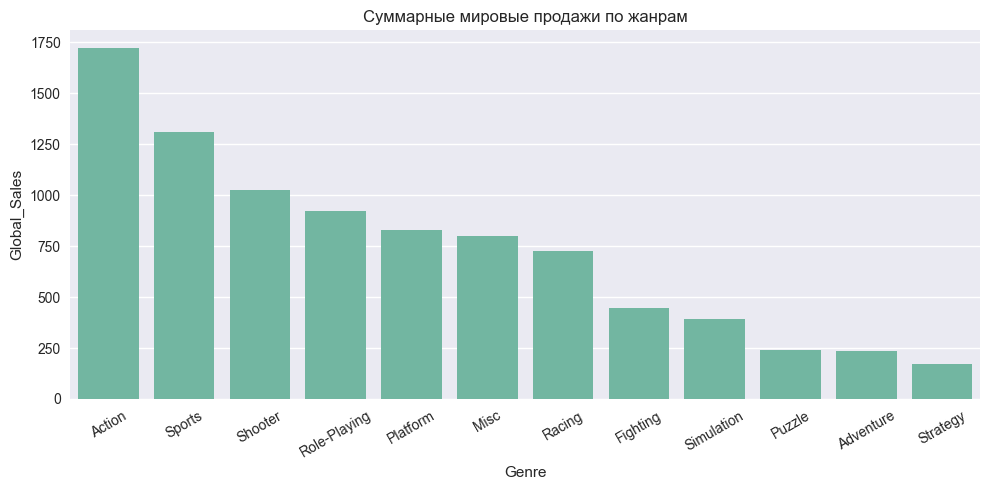

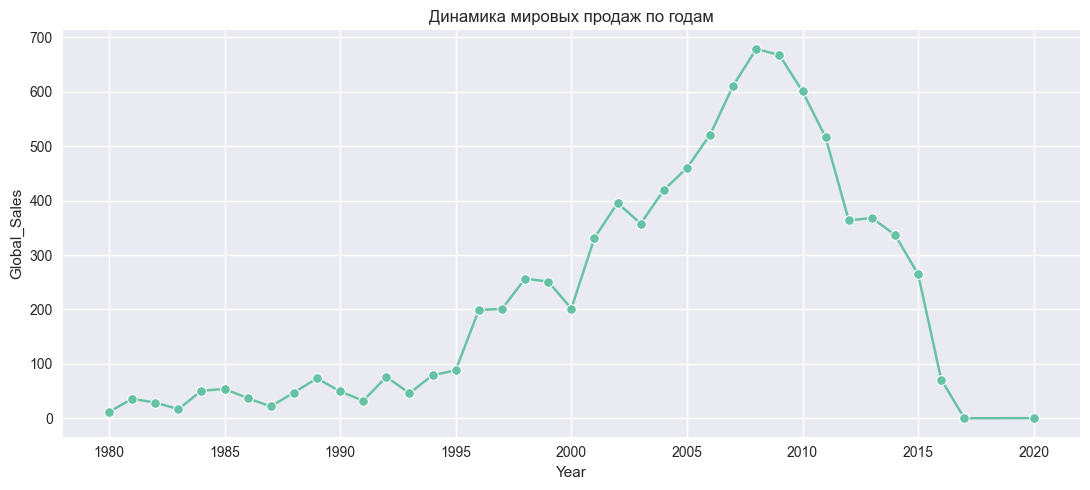

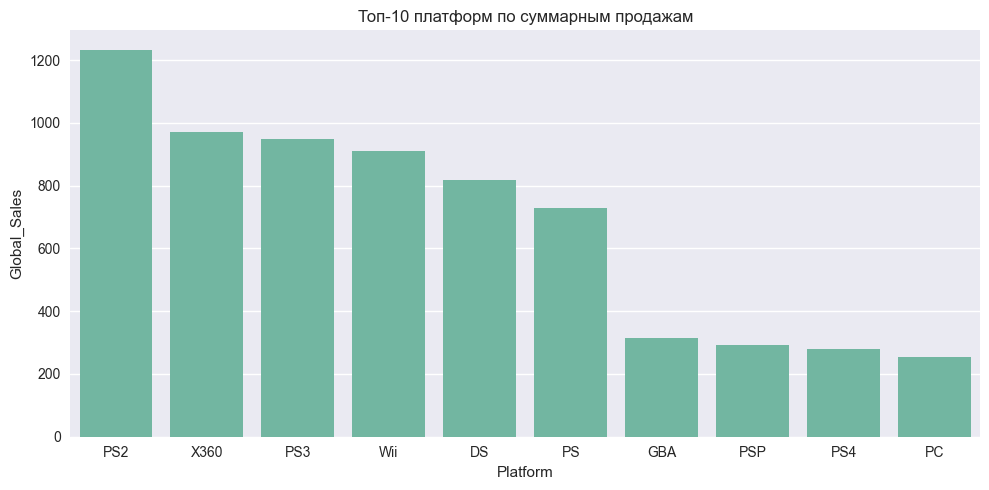

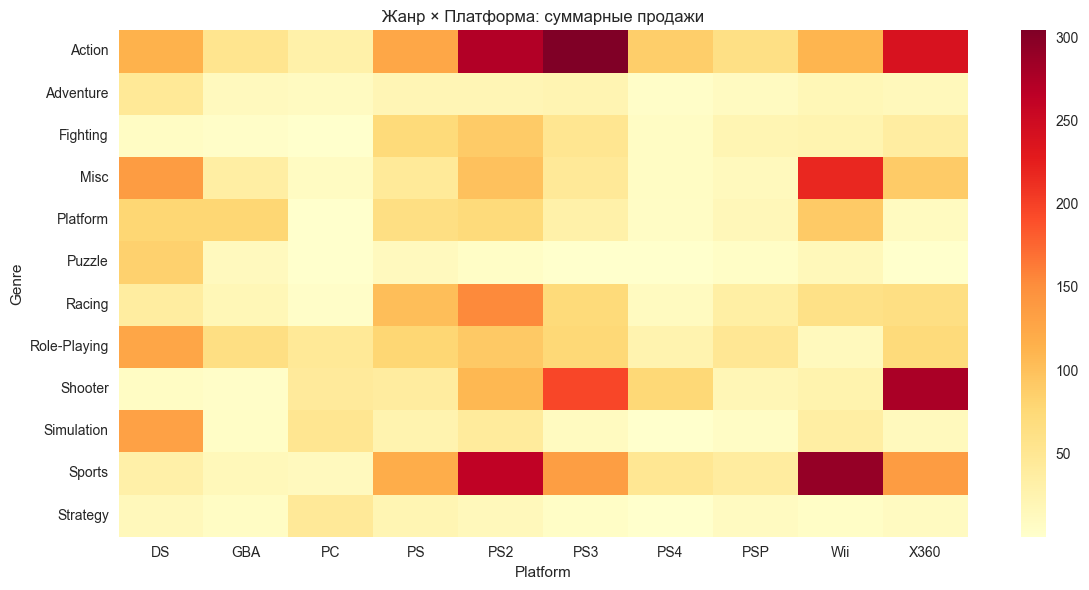

In [5]:
top_genres = df_clean.groupby('Genre', as_index=False)['Global_Sales'].sum().sort_values('Global_Sales', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_genres, x='Genre', y='Global_Sales')
plt.title('Суммарные мировые продажи по жанрам')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

yearly = df_clean.groupby('Year', as_index=False)['Global_Sales'].sum().sort_values('Year')
plt.figure(figsize=(11, 5))
sns.lineplot(data=yearly, x='Year', y='Global_Sales', marker='o')
plt.title('Динамика мировых продаж по годам')
plt.tight_layout()
plt.show()

top_platforms = (
    df_clean.groupby('Platform', as_index=False)['Global_Sales']
    .sum().sort_values('Global_Sales', ascending=False).head(10)
)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_platforms, x='Platform', y='Global_Sales')
plt.title('Топ-10 платформ по суммарным продажам')
plt.tight_layout()
plt.show()

pivot_gp = (
    df_clean[df_clean['Platform'].isin(top_platforms['Platform'])]
    .pivot_table(index='Genre', columns='Platform', values='Global_Sales', aggfunc='sum', fill_value=0)
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_gp, cmap='YlOrRd')
plt.title('Жанр × Платформа: суммарные продажи')
plt.tight_layout()
plt.show()

**Вывод по визуализации:** основные продажи сосредоточены в ограниченном наборе жанров и платформ; перспективнее выбирать не просто жанр, а комбинацию `жанр + платформа`.

## 5. Корреляция и проверка взаимосвязей

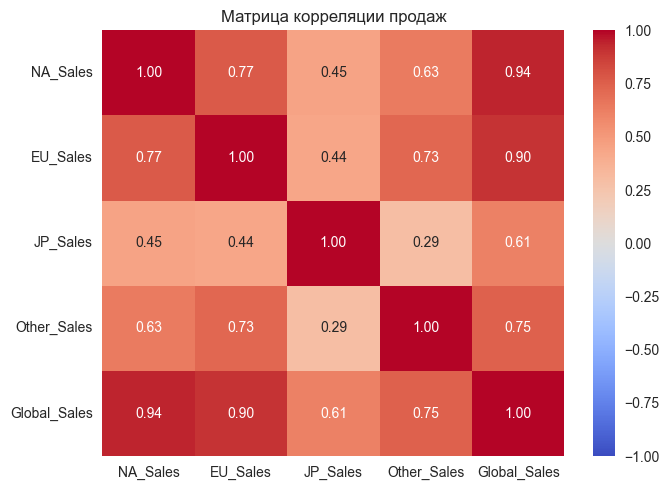

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.00,0.77,0.45,0.63,0.94
EU_Sales,0.77,1.00,0.44,0.73,0.90
JP_Sales,0.45,0.44,1.00,0.29,0.61
Other_Sales,0.63,0.73,0.29,1.00,0.75
Global_Sales,0.94,0.90,0.61,0.75,1.00


In [6]:
corr_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляции продаж')
plt.tight_layout()
plt.show()

corr

**Вывод по взаимосвязям:** `Global_Sales` сильно связан с региональными продажами (особенно NA и EU), при этом JP-рынок частично отличается по структуре спроса.

## 6. Личная идея: индекс устойчивости жанра

Оригинальный показатель: `stability_index = mean(Global_Sales) / std(Global_Sales)`.

Он учитывает одновременно доходность и риск (волатильность) жанра.

,mean,std,sum,count,stability_index
Genre,,,,,
Fighting,0.53,0.96,444.05,836,0.55
Strategy,0.26,0.52,173.43,671,0.49
Action,0.53,1.16,"1,722.88",3253,0.45
Shooter,0.80,1.83,"1,026.20",1282,0.44
Simulation,0.46,1.21,390.16,851,0.38
Role-Playing,0.63,1.72,923.84,1471,0.37
Platform,0.95,2.60,829.15,876,0.36
Adventure,0.18,0.51,234.80,1276,0.36
Racing,0.59,1.68,726.77,1226,0.35


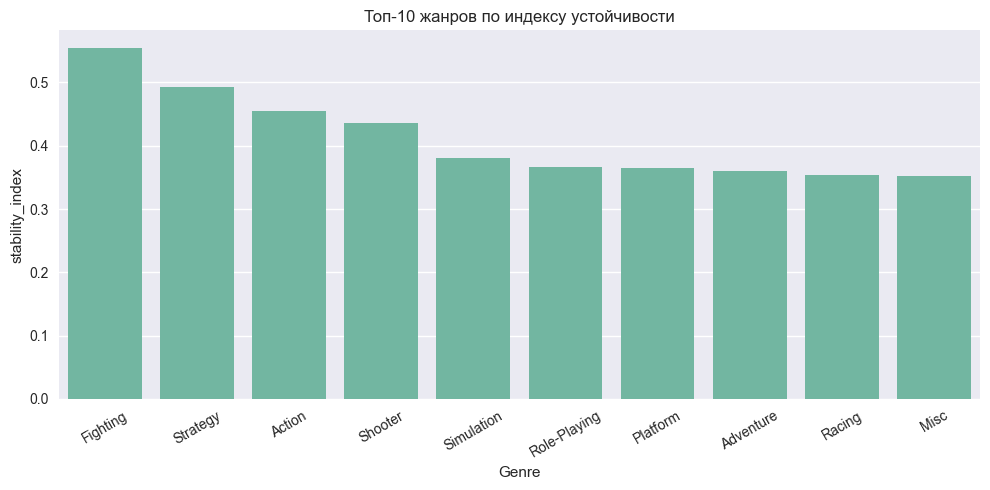

In [7]:
genre_risk = (
    df_clean.groupby('Genre')['Global_Sales']
    .agg(['mean', 'std', 'sum', 'count'])
    .query('count >= 30')
    .copy()
)
genre_risk['stability_index'] = genre_risk['mean'] / genre_risk['std']
genre_risk = genre_risk.sort_values('stability_index', ascending=False)

display(genre_risk.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_risk.reset_index().head(10), x='Genre', y='stability_index')
plt.title('Топ-10 жанров по индексу устойчивости')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Общий вывод и рекомендации

1. Цель исследования достигнута: по данным продаж можно выделить наиболее перспективные жанры для потенциальной разработки.
2. Гипотеза подтверждается: существует жанр (и особенно связка `жанр + платформа`), который продается лучше остальных.
3. Для запуска новой игры целесообразно приоритизировать жанры-лидеры по суммарным продажам и проверять их на наиболее сильных платформах.
4. Планирование продукта стоит делать с учетом региональных различий: структура спроса JP отличается от NA/EU.
5. Для практического выбора направления рекомендуется использовать две метрики одновременно:
   - потенциал (`sum Global_Sales`),
   - риск/предсказуемость (`stability_index`).

Итоговая рекомендация: выбирать концепт новой игры на пересечении трех факторов — жанр, платформа и регион продаж; это повышает вероятность коммерчески успешного релиза.